# Descarga de imágenes

In [ ]:
!gdown 1IGYI4jA5vnkkwlkpE-KbaQBCXSZ2OV4p
!gdown 1txXax0YIq-gyt9xvpcbwYQjmAEpV-aeZ

In [22]:
import gdown

file_id = "1IGYI4jA5vnkkwlkpE-KbaQBCXSZ2OV4p"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "IMG2.jpeg", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1IGYI4jA5vnkkwlkpE-KbaQBCXSZ2OV4p
To: d:\Programacion_Grafica\PC1\IMG2.jpeg
100%|██████████| 1.60M/1.60M [00:00<00:00, 5.34MB/s]


'IMG2.jpeg'

In [23]:
import gdown

file_id = "1txXax0YIq-gyt9xvpcbwYQjmAEpV-aeZ"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "IMG1.jpeg", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1txXax0YIq-gyt9xvpcbwYQjmAEpV-aeZ
To: d:\Programacion_Grafica\PC1\IMG1.jpeg
100%|██████████| 1.61M/1.61M [00:00<00:00, 4.90MB/s]


'IMG1.jpeg'

# Su código aquí

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [25]:
img = cv2.imread('IMG1.jpeg')[:,:,::-1]
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)

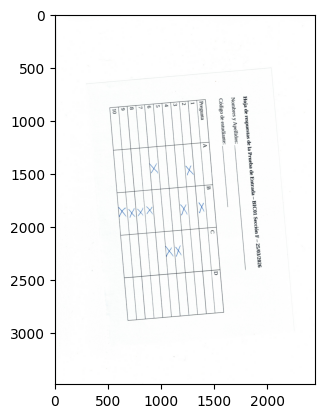

In [26]:
plt.imshow(img)

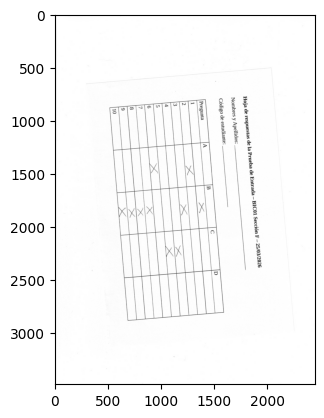

In [27]:
plt.imshow(gray, cmap = 'gray')

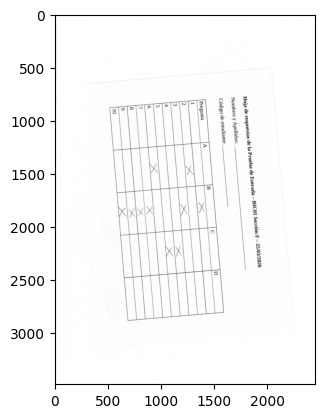

In [28]:
plt.imshow(blur, cmap = 'gray')

In [30]:
edges = cv2.Canny(blur, 50, 150)

In [31]:
edges

array([[  0,   0,   0, ...,   0,   0, 255],
       [  0,   0,   0, ..., 255, 255, 255],
       [  0,   0,   0, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]],
      shape=(3484, 2448), dtype=uint8)

In [32]:
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

contours = sorted(contours, key=cv2.contourArea, reverse=True)

for cnt in contours:
    peri = cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)

    if len(approx) == 4:
        sheet = approx
        break

In [33]:
pts = sheet.reshape(4,2)

In [34]:
pts

array([[1417,  804],
       [ 514,  881],
       [ 686, 2887],
       [1590, 2810]], dtype=int32)

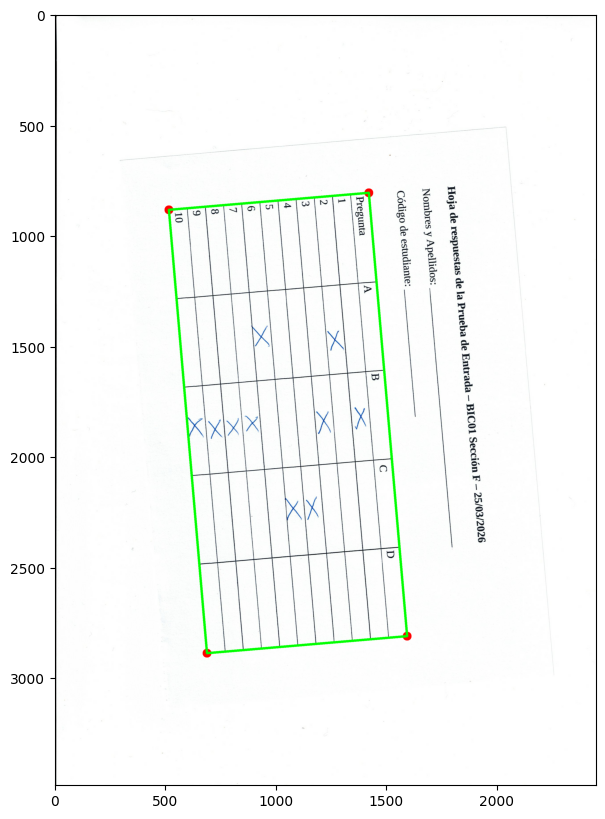

In [38]:
#Definimos los puntos de las esquinas del papel
#Dibujamos los puntos y el poligono en la imagen
puntos = np.float32([[1417,804], [514,881],[686,2887],[1590,2810],])

imgDibujo = img.copy()


cv2.circle(imgDibujo, (1417, 804), 20, (255,0,0), -1)
cv2.circle(imgDibujo, (514, 881), 20, (255,0,0), -1)
cv2.circle(imgDibujo, (686, 2887), 20, (255,0,0), -1)
cv2.circle(imgDibujo, (1590, 2810), 20, (255,0,0), -1)

pts = puntos.reshape((-1,1,2))
cv2.polylines(imgDibujo, [pts.astype(np.int32)], True, (0,255,0), thickness=10)

plt.figure(figsize=(10,10))
plt.imshow(imgDibujo)
plt.show()

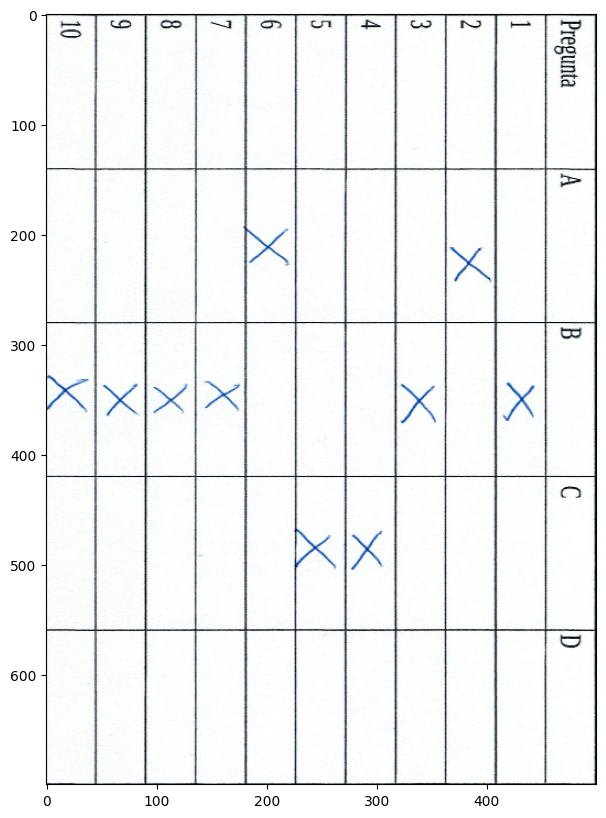

In [113]:
width = 500
height = 700

# Hacemos la transformacion
target = np.float32([[0,0],[width,0],[width,height],[0,height]])

       
matrix = cv2.getPerspectiveTransform(puntos, target)
result = cv2.warpPerspective(img, matrix, (width,height))

 #solo quiero invertir la imagen
result = result[:,::-1,] 

plt.figure(figsize=(10,10))
plt.imshow(result)
plt.show()

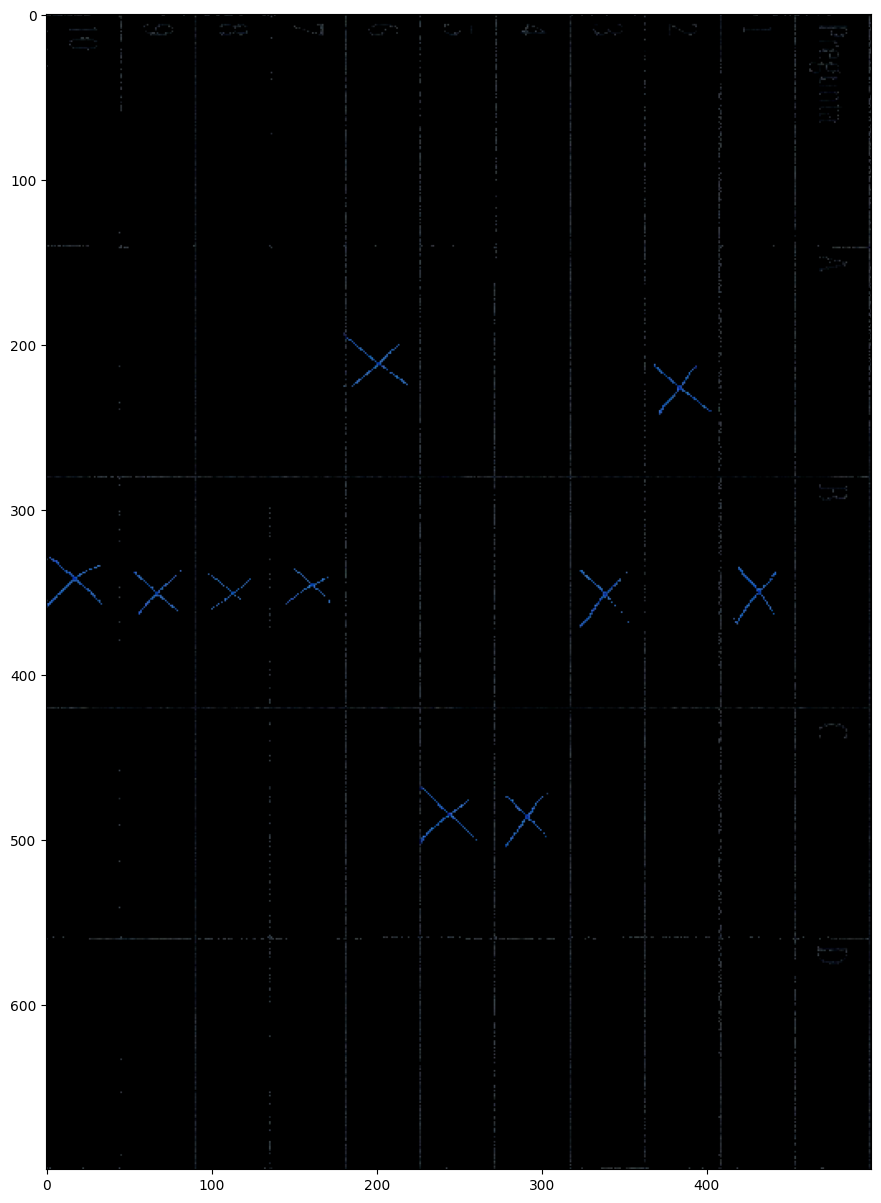

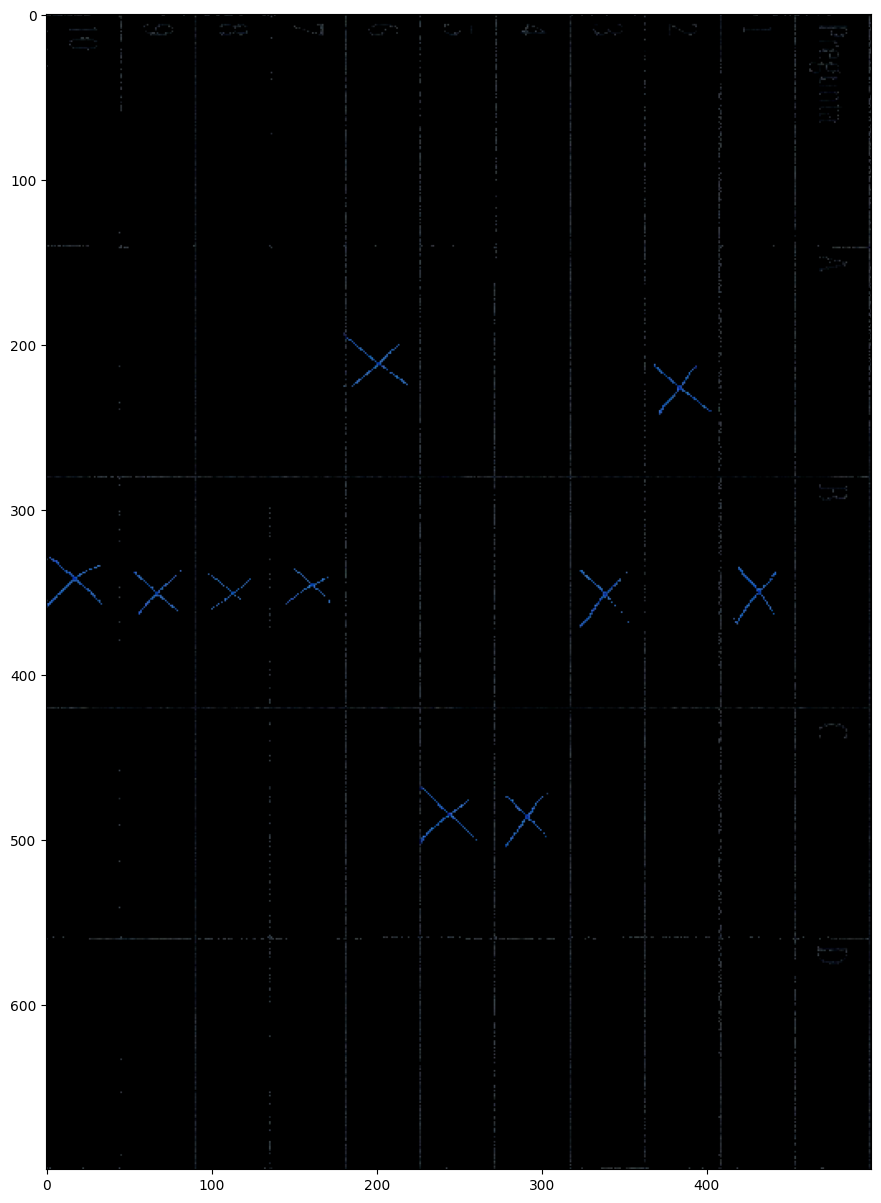

In [ ]:
#limites de color azul para el trabajo
lower_azul = np.array([0,0,0]) #minimo azul
upper_azul = np.array([60,160,255]) #maximo azul

#Buscamos todos los pixeles que estan entre el minimo y maximo azul
mask = cv2.inRange(result, lower_azul, upper_azul)

#Obtenemos solo los pixeles que tienen las propiedades definidas
res = cv2.bitwise_and(result, result, mask = mask)

plt.figure(figsize=(15,15))
plt.imshow(res)
plt.show()


#Buscamos todos los pixeles que estan entre el minimo y maximo azul
mask2 = cv2.inRange(result, lower_azul, upper_azul)

#Obtenemos solo los pixeles que tienen las propiedades definidas
res2 = cv2.bitwise_and(result, result, mask = mask2)

plt.figure(figsize=(15,15))
plt.imshow(res2)
plt.show()

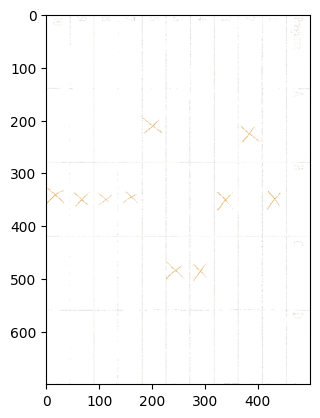

In [118]:
# también podemos invertir la imagen para verla un poco mejor.
res3 = 255 - res
plt.imshow(res3)

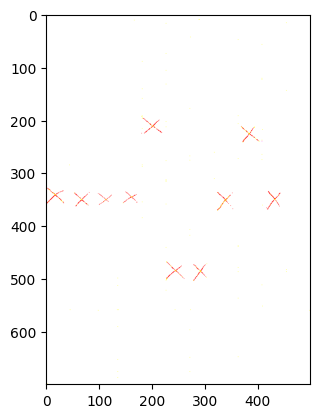

In [119]:
t =180
im_th = res3.copy()
im_th[im_th<t] = 0
im_th[im_th>=t] = 255
# binarizar la imagen (2 valores)
plt.figure()
plt.imshow(im_th, cmap='gray')

In [125]:

blur = cv2.GaussianBlur(im_th, (5,5), 0)
edges = cv2.Canny(blur, 50, 150)


contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

contours = sorted(contours, key=cv2.contourArea, reverse=True)

for cnt in contours:
    peri = cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)

    if len(approx) == 20:
        sheet = approx
        break
    
    

In [130]:
pts = sheet.reshape(-1, 1, 2)

In [131]:
pts

array([[[242, 488]],

       [[229, 499]],

       [[228, 503]],

       [[229, 500]]], dtype=int32)

# Su respuesta a las preguntas teóricas aquí

A.- AL SER PERSONAS DALTONICAS, ESTAS SOLO PERCIBEN LA IMAGENES EN ESCALA DE GRISES, NO PUDIENDO APRECIAR LA GAMA DE COLORES. OSEA EL GAMUT DE SUS OJOS SOLO SE REDUCE A ESCALA GRISES.

B.- ESTO QUE AL PASAR EL FILTRO, LA FIGURA SE DESCOMPONE EN 50% ROJO, 25% VERDE Y 25% AZUL. AL QUERER RECONSTRUIR LA IMAGEN, DEBIDO A ESTO, NO SE PUEDE RECONSTRUIR FIELMENTE.

C.- LA IMAGEN SALE NEGRA, ESTO SE DEBE QUE PRIMERO QUEDO UN RANGO DE VALORES(UNA BANDA) QUE PASA LA SEÑAL Y LUEGO LE PASAMOS UN REZACHA BANDA(MISMA BANDA ANTERIOR) EL CUAL ES SU ANTAGONICO DE PASABANDA, HACIENDO QUE LA BANDA QUE QUEDO LO RECHAZE, ANULANDOSE TOTALMENTE LA IMAGEN, QUEDANDO COLOR NEGRO

D.- EN TEORIA PASAR DE DOMINIO DE FRECUENCIAS AL DOMINIO DEL ESPACIO NO DEBERIA PERDERSE INFORMACION, PERO ESTO EN LA PRACTICA ES FALSO, YA QUE SE TIENE QUE HACER SUMAS INFINITAS DE LAS FRECUENCIAS QUE COMPONEN LA IMAGEN, Y COMPUTACIONALMENTE SOLO SE TRABAJA CON SUMAS FINITAS. 